# Month 2 — Combined Dataset Reliability & Agreement Pipeline

This notebook evaluates **probability calibration**, **subgroup fairness (including source_site)**, and **per-patient model agreement** on the **combined 4-site UCI Heart Disease dataset** (N=920).


In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Ensure src module is in path
sys.path.append('..')

from src.preprocessing import load_combined_dataset
from src.evaluation import evaluate_nested_cv
from src.calibration import plot_calibration_curves
from src.fairness import compute_fairness_breakdown

# Load configuration
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded successfully.")


Configuration loaded successfully.


## 1. Execute Out-of-Fold Nested Cross-Validation Pipeline
Run 5-fold outer / 3-fold inner nested CV on the 920-patient combined dataset with out-of-sample calibration tracking and model agreement logging.


In [2]:
results_dir = '../' + config['results_dir']
df_combined = load_combined_dataset('../data', results_dir)

print("Running nested cross-validation with out-of-fold calibration and agreement tracking...")
results = evaluate_nested_cv(
    df_combined,
    target_col='target',
    outer_splits=config['cv']['outer_folds'],
    inner_splits=config['cv']['inner_folds'],
    n_trials=config['cv']['optuna_n_trials'],
    random_state=config['random_state']
)

print("Nested CV evaluation completed.")


Running nested cross-validation with out-of-fold calibration and agreement tracking...


Nested CV evaluation completed.


## 2. Probability Calibration Comparison (Combined Dataset)
Evaluate Brier Score Loss and Expected Calibration Error (ECE) for Uncalibrated vs. Platt Scaling vs. Isotonic Regression.


In [3]:
cal_rows = []
model_names = ['random_forest', 'xgboost', 'adaboost', 'ensemble']

for model_name in model_names:
    m_data = results[model_name]
    cal = m_data['calibration']
    for method in ['uncalibrated', 'platt', 'isotonic']:
        cal_rows.append({
            'Model': model_name.upper(),
            'Calibration Method': method.capitalize(),
            'Brier Score (Lower is better)': f"{cal[method]['brier']:.4f}",
            'ECE (Lower is better)': f"{cal[method]['ece']:.4f}"
        })

cal_summary_df = pd.DataFrame(cal_rows)
print("=== Probability Calibration Comparison (Out-Of-Fold Combined Dataset) ===")
display(cal_summary_df)


=== Probability Calibration Comparison (Out-Of-Fold Combined Dataset) ===


,Model,Calibration Method,Brier Score (Lower is better),ECE (Lower is better)
0,RANDOM_FOREST,Uncalibrated,0.1336,0.0656
1,RANDOM_FOREST,Platt,0.1296,0.0230
2,RANDOM_FOREST,Isotonic,0.1352,0.0334
3,XGBOOST,Uncalibrated,0.1300,0.0426
4,XGBOOST,Platt,0.1258,0.0182
5,XGBOOST,Isotonic,0.1289,0.0320
6,ADABOOST,Uncalibrated,0.1730,0.1980
7,ADABOOST,Platt,0.1292,0.0326
8,ADABOOST,Isotonic,0.1350,0.0293
9,ENSEMBLE,Uncalibrated,0.1383,0.1058


### Plot Calibration Curves for Combined Dataset
Save calibration plots with `combined_` prefix to `results/`.


Saved calibration curve: ../results/combined_random_forest_calibration_curve.png


Saved calibration curve: ../results/combined_xgboost_calibration_curve.png


Saved calibration curve: ../results/combined_adaboost_calibration_curve.png


Saved calibration curve: ../results/combined_ensemble_calibration_curve.png

Displaying Combined Ensemble Calibration Curve:


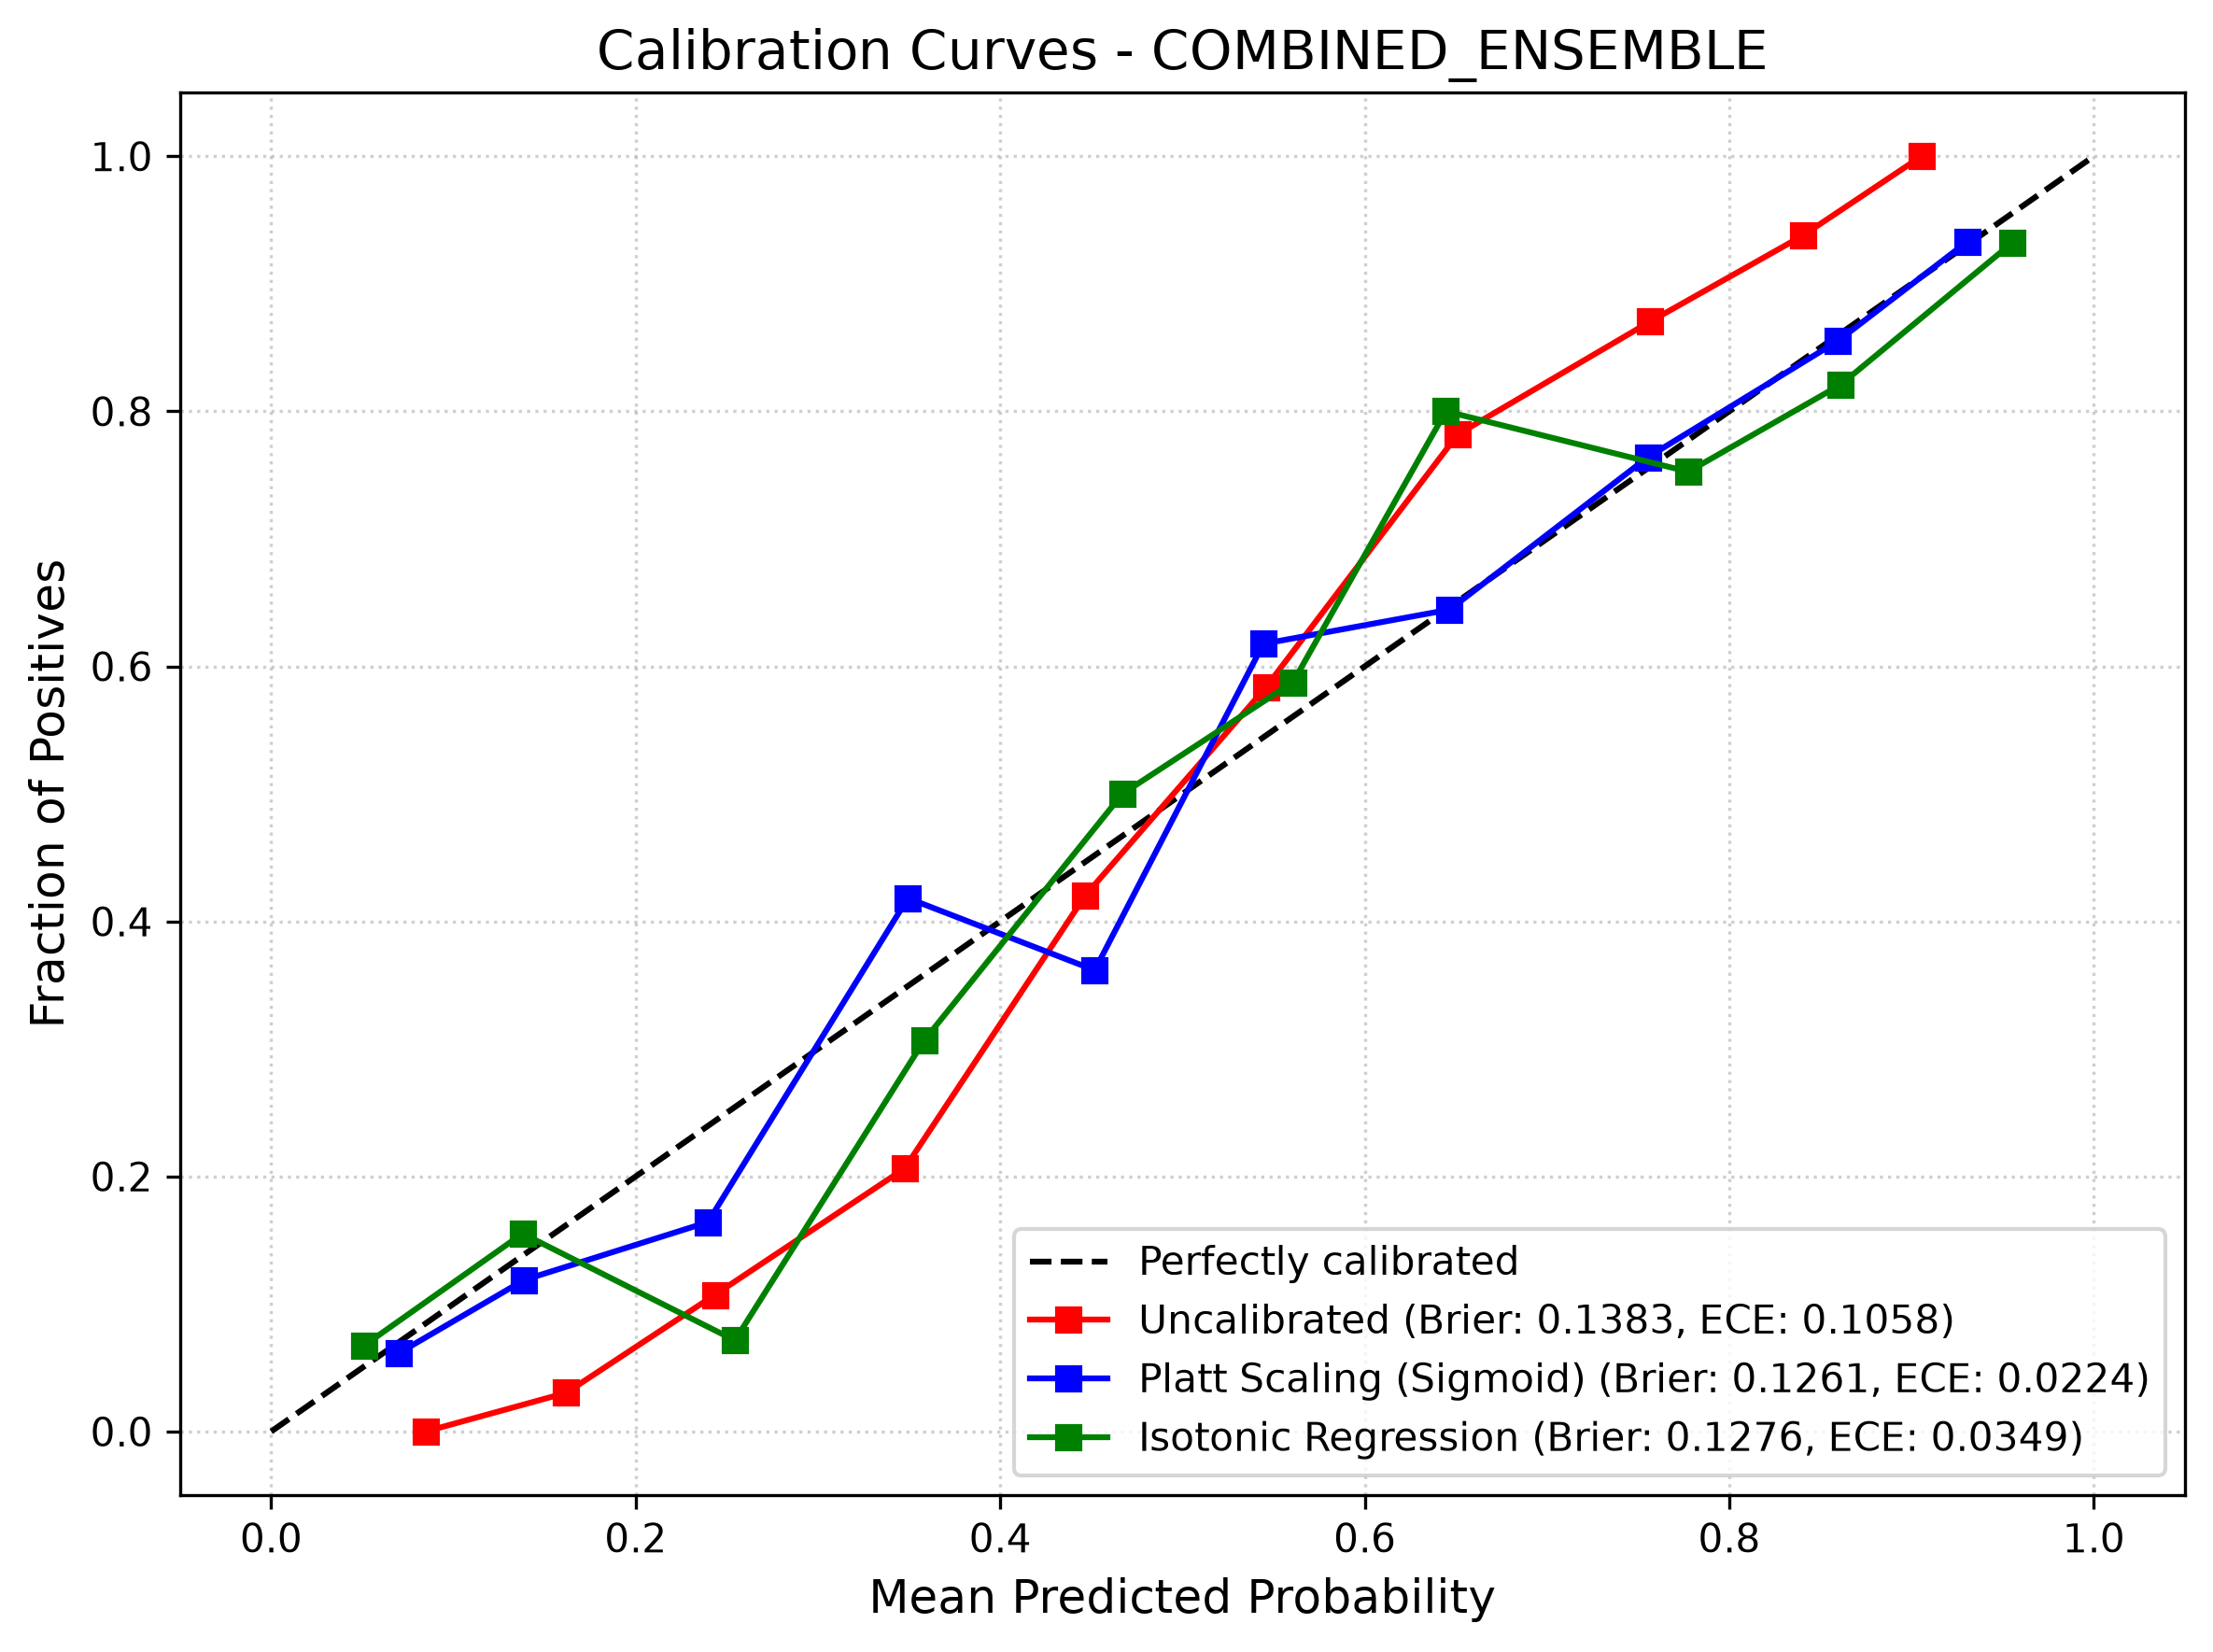

In [4]:
for model_name in model_names:
    m_data = results[model_name]
    curve_path = plot_calibration_curves(
        m_data['calibration'],
        model_name=f"combined_{model_name}",
        output_dir=results_dir,
        n_bins=10
    )
    print(f"Saved calibration curve: {curve_path}")

print("\nDisplaying Combined Ensemble Calibration Curve:")
display(Image(filename=f"{results_dir}/combined_ensemble_calibration_curve.png"))


## 3. Subgroup Fairness & Per-Site Analysis
Evaluate performance across `sex`, `age_band`, and `source_site` (Cleveland, Hungarian, Switzerland, VA Long Beach).


In [5]:
ensemble_oof = results['ensemble']['out_of_fold_predictions']
oof_df = df_combined.iloc[ensemble_oof['test_indices']].reset_index(drop=True)

y_true_oof = np.array(ensemble_oof['y_true'])
y_pred_oof = np.array(ensemble_oof['y_pred'])
y_prob_oof = np.array(ensemble_oof['y_prob_platt'])  # Platt calibrated probabilities

fairness_res = compute_fairness_breakdown(
    oof_df, y_true_oof, y_pred_oof, y_prob_oof, target_col='target'
)

print(f"=== {fairness_res['caveat']} ===\n")

print("--- Performance Breakdown by Sex ---")
display(fairness_res['sex_breakdown'])

print("\n--- Performance Breakdown by Age Band ---")
display(fairness_res['age_breakdown'])

print("\n--- Performance Breakdown by Source Site ---")
display(fairness_res['site_breakdown'])


=== NOTE / CAVEAT: Subgroup sample sizes in healthcare datasets (e.g. per-site or female cohorts) can be small or imbalanced (e.g. Switzerland N=123, VA N=200). Performance breakdowns across subgroups should be interpreted as indicative/exploratory rather than statistically conclusive. ===

--- Performance Breakdown by Sex ---


,subgroup,sample_size,accuracy,recall,roc_auc
0,Female (0),194,0.871134,0.720000,0.879722
1,Male (1),726,0.816804,0.873638,0.874830



--- Performance Breakdown by Age Band ---


,subgroup,sample_size,accuracy,recall,roc_auc
0,50-60,407,0.810811,0.864979,0.881013
1,< 50,292,0.869863,0.765766,0.901548
2,> 60,221,0.805430,0.913043,0.838716



--- Performance Breakdown by Source Site ---


,subgroup,sample_size,accuracy,recall,roc_auc
0,cleveland,303,0.831683,0.812950,0.900991
1,hungarian,294,0.833333,0.764151,0.880620
2,switzerland,123,0.943089,0.982609,0.713043
3,va_long_beach,200,0.745000,0.872483,0.720490


## 4. Per-Patient Model Agreement Analysis
Analyze consensus among RF, XGBoost, and AdaBoost base classifiers across the 920-patient combined cohort.


In [6]:
agreement_data = results['agreement_analysis']
df_patients = agreement_data['patient_df']
summary_table = agreement_data['summary_table']

print("=== Model Agreement Breakdown on Combined Dataset ===")
display(summary_table)

plt.figure(figsize=(9, 5))
sns.histplot(df_patients['std_dev'], bins=20, kde=True, color='teal', edgecolor='black')
plt.axvline(x=0.05, color='green', linestyle='--', label='High Agreement Boundary (std < 0.05)')
plt.axvline(x=0.15, color='red', linestyle='--', label='Low Agreement Boundary (std >= 0.15)')

plt.xlabel('Base Model Probability Std Dev', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.title('Combined Dataset Model Agreement Score Distribution', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig(f"{results_dir}/combined_model_agreement_distribution.png", dpi=300)
plt.show()


=== Model Agreement Breakdown on Combined Dataset ===


,Agreement Level,Sample Size (N),% of Total Patients,Accuracy
0,high agreement,167,18.2%,0.652695
1,moderate agreement,753,81.8%,0.867198
2,low agreement,0,0.0%,NaN
